In [43]:
!pip install xgboost lightgbm  joblib imbalanced-learn

We are going to load the data, the train different models and compare them

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

In [55]:
url = "https://raw.githubusercontent.com/irungus/tree-species-ml-pipeline/main/data/processed/features.csv"
df = pd.read_csv(url)

print(df.head())
print(f"Total points: {len(df)}")

       NDVI       EVI      SAVI  ...     slope  VV_VH_ratio     species
0  0.251262  0.476082  0.376848  ...  4.732799     0.709569      Acacia
1  0.334040  0.711032  0.501006  ...  1.313490     0.738975  Eucalyptus
2  0.334040  0.711032  0.501006  ...  1.313490     0.738975  Eucalyptus
3  0.334040  0.711032  0.501006  ...  1.313490     0.738975  Eucalyptus
4  0.298845  1.502694  0.448226  ...  3.716075     0.447886  Eucalyptus

[5 rows x 13 columns]
Total points: 3071


In [56]:
 X = df.drop('species', axis=1)
 y = df['species']

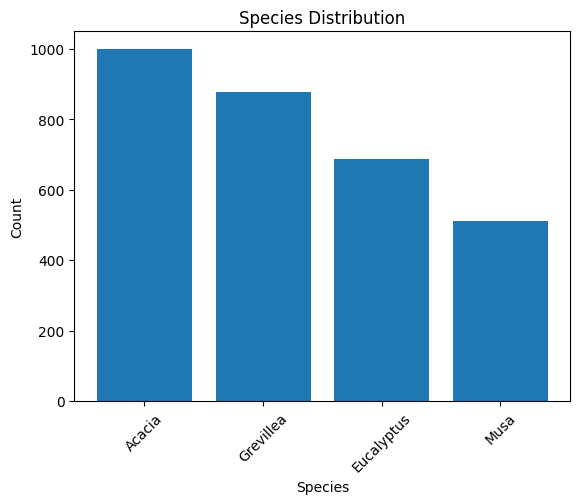

In [57]:
species_counts = df['species'].value_counts()

plt.figure()
plt.bar(species_counts.index, species_counts.values)
plt.xticks(rotation=45)
plt.xlabel("Species")
plt.ylabel("Count")
plt.title("Species Distribution")
plt.show()

In [58]:
# Encode target
le = LabelEncoder()
y = le.fit_transform(df['species'])

print("Classes:", list(le.classes_))

Classes: ['Acacia', 'Eucalyptus', 'Grevillea', 'Musa']


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_resampled))

Before SMOTE: [699 480 613 357]
After SMOTE: [699 699 699 699]


In [65]:
# Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_resampled, y_resampled)

# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)
xgb.fit(X_resampled, y_resampled)

# LightGBM
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)
lgbm.fit(X_resampled, y_resampled)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000828 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3028
[LightGBM] [Info] Number of data points in the train set: 2796, number of used features: 12
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42)

In [66]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    return accuracy_score(y_test, y_pred), y_pred

In [67]:
rf_acc, rf_pred = evaluate_model(rf, X_test_scaled, y_test, "Random Forest")
xgb_acc, xgb_pred = evaluate_model(xgb, X_test_scaled, y_test, "XGBoost")
lgbm_acc, lgbm_pred = evaluate_model(lgbm, X_test_scaled, y_test, "LightGBM")


=== Random Forest ===
Accuracy: 0.7494577006507592

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       300
           1       0.71      0.69      0.70       206
           2       0.67      0.69      0.68       263
           3       0.61      0.62      0.62       153

    accuracy                           0.75       922
   macro avg       0.73      0.73      0.73       922
weighted avg       0.75      0.75      0.75       922


=== XGBoost ===
Accuracy: 0.7505422993492408

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       300
           1       0.72      0.70      0.71       206
           2       0.66      0.67      0.66       263
           3       0.61      0.63      0.62       153

    accuracy                           0.75       922
   macro avg       0.73      0.73      0.73       922
weighted avg       0.75      0.75    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM ===
Accuracy: 0.7516268980477223

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       300
           1       0.72      0.69      0.71       206
           2       0.66      0.69      0.68       263
           3       0.61      0.62      0.61       153

    accuracy                           0.75       922
   macro avg       0.73      0.73      0.73       922
weighted avg       0.75      0.75      0.75       922



In [68]:
y_test_labels = le.inverse_transform(y_test)
xgb_labels = le.inverse_transform(xgb_pred)

print(pd.DataFrame({
    "Actual": y_test_labels,
    "Predicted": xgb_labels
}).head())

       Actual   Predicted
0      Acacia      Acacia
1        Musa        Musa
2   Grevillea   Grevillea
3  Eucalyptus  Eucalyptus
4      Acacia      Acacia


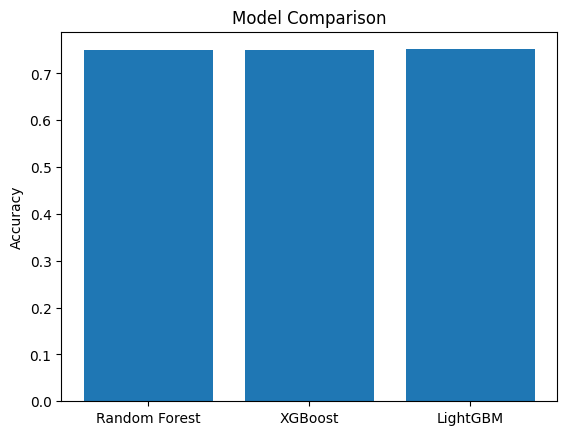

In [69]:
models = ["Random Forest", "XGBoost", "LightGBM"]
scores = [rf_acc, xgb_acc, lgbm_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [73]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params,
    n_iter=10,
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_resampled, y_resampled)

best_rf = rf_search.best_estimator_
print("Best RF Params:", rf_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}


In [74]:
xgb_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    xgb_params,
    n_iter=10,
    cv=3,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_resampled, y_resampled)

best_xgb = xgb_search.best_estimator_
print("Best XGB Params:", xgb_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGB Params: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [75]:
lgbm_params = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'max_depth': [-1, 10, 20]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42),
    lgbm_params,
    n_iter=10,
    cv=3,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_resampled, y_resampled)

best_lgbm = lgbm_search.best_estimator_
print("Best LGBM Params:", lgbm_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000615 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3028
[LightGBM] [Info] Number of data points in the train set: 2796, number of used features: 12
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Best LGBM Params: {'num_leaves': 31, 'n_estimators': 300, 'max_depth': 20, 'learning_rate': 0.1}


In [76]:
def evaluate(model, name):
    y_pred = model.predict(X_test_scaled)

    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return accuracy_score(y_test, y_pred)

In [77]:
rf_acc = evaluate(best_rf, "Random Forest (Tuned)")
xgb_acc = evaluate(best_xgb, "XGBoost (Tuned)")
lgbm_acc = evaluate(best_lgbm, "LightGBM (Tuned)")


=== Random Forest (Tuned) ===
Accuracy: 0.745119305856833
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       300
           1       0.70      0.70      0.70       206
           2       0.68      0.68      0.68       263
           3       0.60      0.61      0.60       153

    accuracy                           0.75       922
   macro avg       0.72      0.72      0.72       922
weighted avg       0.75      0.75      0.75       922


=== XGBoost (Tuned) ===
Accuracy: 0.7570498915401301
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       300
           1       0.73      0.70      0.71       206
           2       0.68      0.69      0.68       263
           3       0.61      0.64      0.63       153

    accuracy                           0.76       922
   macro avg       0.74      0.74      0.74       922
weighted avg       0.76      0.76      0.76       922


=== LightGBM (Tu

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


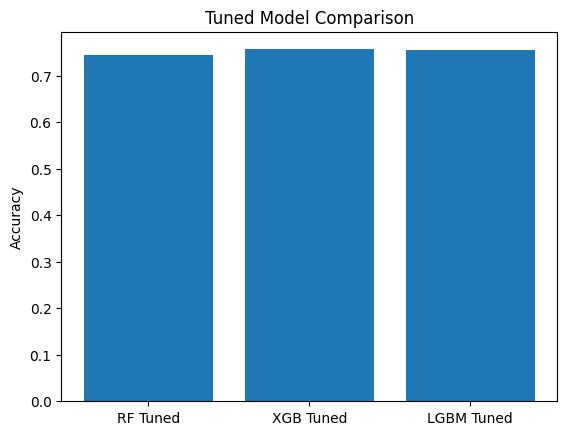

In [78]:
import matplotlib.pyplot as plt

models = ["RF Tuned", "XGB Tuned", "LGBM Tuned"]
scores = [rf_acc, xgb_acc, lgbm_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Tuned Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [79]:
best_model = max(
    [(best_rf, rf_acc), (best_xgb, xgb_acc), (best_lgbm, lgbm_acc)],
    key=lambda x: x[1]
)[0]

print("Best Model Selected:", best_model)

Best Model Selected: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)


In [80]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']